**Asignatura:** Data Analytics  
**Modalidad:** trabajo autónomo en Google Colab  
**Duración estimada:** 2 horas y 30 minutos a 3 horas  
**Prerrequisitos:** ninguno

---

**_Propósito_**

Al terminar este taller podrá:

1. utilizar celdas de texto y código en Google Colab;
2. trabajar con variables, tipos de datos, listas y diccionarios;
3. construir condiciones, ciclos y funciones;
4. organizar datos tabulares con `pandas`;
5. calcular KPI básicos de ventas y margen;
6. producir una visualización sencilla;
7. verificar automáticamente cada ejercicio y recibir pistas progresivas.


## Antes de comenzar

1. Abra el archivo en **Google Colab**.
2. Seleccione **Archivo → Guardar una copia en Drive**.
3. Ejecute las celdas en orden mediante el botón ▶.
4. Edite únicamente las celdas marcadas con `# TODO`.
5. Después de cada ejercicio, ejecute la celda **Autoevaluación**.
6. Si la respuesta no es correcta:
   - primer intento: recibirá una pista;
   - segundo intento: recibirá una pista más específica;
   - tercer intento: aparecerá una solución de emergencia.

### Convenciones

- ✅ ejercicio aprobado;
- 🟡 respuesta todavía incorrecta;
- 🧩 pista de apoyo;
- 🛟 solución de emergencia;
- 📊 progreso acumulado.

**Importante:** equivocarse no reduce el puntaje. El objetivo es llegar a una solución correcta y comprenderla.

# 0. Prepare el entorno

Ejecute la siguiente celda una sola vez. Esta celda:

- importa las bibliotecas necesarias;
- activa el sistema de autoevaluación;
- conserva el puntaje aunque vuelva a ejecutar otras celdas;
- permite exportar el resultado final.

In [ ]:
import math
import json
import html
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import display, HTML

PUNTAJES = {
    "E1": 8,
    "E2": 5,
    "E3": 8,
    "E4": 8,
    "E5": 8,
    "E6": 10,
    "E7": 10,
    "E8": 10,
    "E9": 12,
    "E10": 7,
    "E11": 14,
}

if "RESULTADOS" not in globals():
    RESULTADOS = {}
if "INTENTOS" not in globals():
    INTENTOS = {}

def _tarjeta(mensaje, color_fondo, color_borde):
    display(HTML(
        f"""
        <div style="padding:14px 18px;margin:10px 0;border-radius:10px;
                    background:{color_fondo};border-left:6px solid {color_borde};">
            {mensaje}
        </div>
        """
    ))

def evaluar(ejercicio, prueba, pistas, solucion):
    """Ejecuta una prueba sin bloquear el cuaderno y entrega apoyo progresivo."""
    try:
        aprobado = bool(prueba())
        detalle_error = ""
    except Exception as exc:
        aprobado = False
        detalle_error = f"{type(exc).__name__}: {exc}"

    if aprobado:
        RESULTADOS[ejercicio] = PUNTAJES[ejercicio]
        _tarjeta(
            f"<b>✅ {ejercicio} aprobado.</b> Obtuvo {PUNTAJES[ejercicio]} puntos.",
            "#eaf7ef", "#2e8b57"
        )
        return True

    INTENTOS[ejercicio] = INTENTOS.get(ejercicio, 0) + 1
    intento = INTENTOS[ejercicio]
    RESULTADOS.setdefault(ejercicio, 0)

    mensaje = f"<b>🟡 {ejercicio}: todavía no es correcto.</b><br>"
    if detalle_error:
        mensaje += f"<span style='color:#8a3b12;'>Detalle técnico: {html.escape(detalle_error)}</span><br>"

    if intento == 1:
        mensaje += f"<b>🧩 Pista 1:</b> {html.escape(pistas[0])}"
    elif intento == 2:
        mensaje += f"<b>🧩 Pista 2:</b> {html.escape(pistas[1])}"
    else:
        mensaje += (
            "<b>🛟 Solución de emergencia:</b><br>"
            f"<pre style='background:#fff;padding:10px;border-radius:6px;'>"
            f"{html.escape(solucion)}</pre>"
            "Copie la solución en la celda del ejercicio, ejecútela y vuelva a comprobar."
        )

    _tarjeta(mensaje, "#fff7e6", "#f0a000")
    return False

def mostrar_progreso():
    total = sum(RESULTADOS.get(e, 0) for e in PUNTAJES)
    porcentaje = total
    aprobados = [e for e in PUNTAJES if RESULTADOS.get(e, 0) > 0]
    pendientes = [e for e in PUNTAJES if RESULTADOS.get(e, 0) == 0]

    color = "#2e8b57" if porcentaje >= 80 else "#f0a000" if porcentaje >= 60 else "#b23a48"
    _tarjeta(
        f"<b>📊 Progreso: {total}/100 puntos</b><br>"
        f"Aprobados: {', '.join(aprobados) if aprobados else 'ninguno'}<br>"
        f"Pendientes: {', '.join(pendientes) if pendientes else 'ninguno'}",
        "#f4f7fb", color
    )

def exportar_autoevaluacion(nombre="estudiante"):
    registros = []
    for ejercicio, puntaje_maximo in PUNTAJES.items():
        registros.append({
            "estudiante": nombre,
            "ejercicio": ejercicio,
            "puntaje_obtenido": RESULTADOS.get(ejercicio, 0),
            "puntaje_maximo": puntaje_maximo,
            "intentos": INTENTOS.get(ejercicio, 0),
        })

    resultado = pd.DataFrame(registros)
    nombre_seguro = re.sub(r"[^A-Za-z0-9_-]+", "_", nombre.strip()) or "estudiante"
    archivo = f"autoevaluacion_python_{nombre_seguro}.csv"
    resultado.to_csv(archivo, index=False, encoding="utf-8-sig")

    print(f"Archivo creado: {archivo}")
    display(resultado)

    try:
        from google.colab import files
        files.download(archivo)
    except Exception:
        print("Fuera de Colab, el archivo quedó guardado en el directorio actual.")

print("✅ Entorno preparado. Puede comenzar.")
mostrar_progreso()

✅ Entorno preparado. Puede comenzar.


# 1. Google Colab y las primeras instrucciones

Google Colab organiza el trabajo en dos tipos de celdas:

- **texto:** explica el proceso, documenta decisiones y comunica resultados;
- **código:** ejecuta instrucciones escritas en Python.

En Python:

- `print()` muestra un resultado;
- `#` inicia un comentario;
- el operador `=` asigna un valor a una variable;
- `type()` informa el tipo de un objeto.

In [ ]:
# Ejemplo guiado: ejecute la celda sin modificarla
nombre_restaurante = "Restaurante La Analítica"
numero_sedes = 3
ventas_crecieron = True

print(nombre_restaurante)
print("Sedes:", numero_sedes)
print("Tipo de nombre_restaurante:", type(nombre_restaurante))
print("Tipo de numero_sedes:", type(numero_sedes))
print("Tipo de ventas_crecieron:", type(ventas_crecieron))

Restaurante La Analítica
Sedes: 3
Tipo de nombre_restaurante: <class 'str'>
Tipo de numero_sedes: <class 'int'>
Tipo de ventas_crecieron: <class 'bool'>


## Tipos de datos fundamentales

| Tipo | Ejemplo | Uso habitual en analítica |
|---|---:|---|
| `str` | `"Centro"` | nombres, categorías y etiquetas |
| `int` | `25` | conteos y cantidades |
| `float` | `0.15` | porcentajes, promedios y medidas |
| `bool` | `True` | condiciones lógicas |

## Ejercicio E1 — Variables y operaciones aritméticas (8 puntos)

Una venta corresponde a **3 unidades** de un producto con precio unitario de **$22.000** y descuento del **10 %**.

Calcule:

- `ingreso_bruto`;
- `valor_descuento`;
- `ingreso_neto`.

Recuerde que `10 %` se representa como `0.10`.

In [ ]:
# TODO E1
cantidad = 3
precio_unitario = 22000
descuento = 0.10

ingreso_bruto = cantidad * precio_unitario
valor_descuento = ingreso_bruto * descuento
ingreso_neto = ingreso_bruto - valor_descuento

print("Ingreso bruto:", ingreso_bruto)
print("Descuento:", valor_descuento)
print("Ingreso neto:", ingreso_neto)

Ingreso bruto: 66000
Descuento: 6600.0
Ingreso neto: 59400.0


In [ ]:
# Autoevaluación E1
evaluar(
    "E1",
    lambda: (
        ingreso_bruto == 66000
        and valor_descuento == 6600
        and ingreso_neto == 59400
    ),
    pistas=[
        "Primero multiplique cantidad por precio_unitario.",
        "El descuento en dinero es ingreso_bruto * descuento; luego réstelo del ingreso bruto.",
    ],
    solucion="""
ingreso_bruto = cantidad * precio_unitario
valor_descuento = ingreso_bruto * descuento
ingreso_neto = ingreso_bruto - valor_descuento
"""
)

True

## Ejercicio E2 — Texto y presentación de un KPI (5 puntos)

Una cifra aislada comunica poco. Cree una variable llamada `mensaje_venta` que incluya:

- el nombre `Bowl Andino`;
- el ingreso neto calculado en E1.

Puede usar una cadena formateada:

```python
f"Texto {variable}"
```

In [ ]:
# TODO E2
producto = "Bowl Andino"
mensaje_venta = f"{producto} generó ingresos netos de ${ingreso_neto:,.0f}."

print(mensaje_venta)

Bowl Andino generó ingresos netos de $59,400.


In [ ]:
# Autoevaluación E2
def _comprobar_mensaje():
    texto = str(mensaje_venta)
    digitos = "".join(caracter for caracter in texto if caracter.isdigit())
    return "Bowl Andino" in texto and "59400" in digitos

evaluar(
    "E2",
    _comprobar_mensaje,
    pistas=[
        "Use una f-string e incluya las variables producto e ingreso_neto.",
        "El mensaje debe contener literalmente Bowl Andino y el número 59400, aunque use separador de miles.",
    ],
    solucion='mensaje_venta = f"{producto} generó ingresos netos de ${ingreso_neto:,.0f}."'
)

True

# 2. Listas y diccionarios

## Listas

Una lista guarda varios valores en orden:

```python
productos = ["Bowl", "Pasta", "Ensalada"]
```

La primera posición se identifica con el índice `0`.

## Diccionarios

Un diccionario organiza información mediante pares `clave: valor`:

```python
venta = {
    "cliente_id": 101,
    "producto": "Bowl Andino",
    "cantidad": 2
}
```

Se accede a un dato mediante su clave:

```python
venta["producto"]
```

In [ ]:
# Ejemplo guiado
sedes = ["Centro", "Norte", "Occidente"]
venta_demo = {
    "cliente_id": 101,
    "producto": "Bowl Andino",
    "cantidad": 2,
    "precio_unitario": 24000,
}

print("Primera sede:", sedes[0])
print("Producto vendido:", venta_demo["producto"])

## Ejercicio E3 — Representar una venta (8 puntos)

1. Cree una lista `productos_destacados` con:
   - `"Bowl Andino"`;
   - `"Pasta Urbana"`;
   - `"Ensalada de la Casa"`.
2. Cree un diccionario `venta_ejemplo` con:
   - `cliente_id = 101`;
   - `producto = "Bowl Andino"`;
   - `cantidad = 2`;
   - `precio_unitario = 24000`;
   - `costo_unitario = 14000`.
3. Obtenga el primer producto de la lista.
4. Calcule el margen total de la venta:

`cantidad × (precio unitario − costo unitario)`

In [ ]:
# TODO E3
productos_destacados = ["Bowl Andino", "Pasta Urbana", "Ensalada de la Casa"]

venta_ejemplo = {
    "cliente_id": 101,
    "producto": "Bowl Andino",
    "cantidad": 2,
    "precio_unitario": 24000,
    "costo_unitario": 14000
}

primer_producto = productos_destacados[0]
margen_total_venta = venta_ejemplo["cantidad"] * (
    venta_ejemplo["precio_unitario"] - venta_ejemplo["costo_unitario"]
)

print("Primer producto:", primer_producto)
print("Margen de la venta:", margen_total_venta)

Primer producto: Bowl Andino
Margen de la venta: 20000


In [ ]:
# Autoevaluación E3
evaluar(
    "E3",
    lambda: (
        isinstance(productos_destacados, list)
        and productos_destacados == [
            "Bowl Andino",
            "Pasta Urbana",
            "Ensalada de la Casa",
        ]
        and isinstance(venta_ejemplo, dict)
        and venta_ejemplo["cliente_id"] == 101
        and primer_producto == "Bowl Andino"
        and margen_total_venta == 20000
    ),
    pistas=[
        "Las listas usan corchetes [] y los diccionarios llaves {}.",
        "Acceda al primer elemento con [0]. Para el margen use las claves del diccionario.",
    ],
    solucion="""
productos_destacados = [
    "Bowl Andino",
    "Pasta Urbana",
    "Ensalada de la Casa",
]

venta_ejemplo = {
    "cliente_id": 101,
    "producto": "Bowl Andino",
    "cantidad": 2,
    "precio_unitario": 24000,
    "costo_unitario": 14000,
}

primer_producto = productos_destacados[0]
margen_total_venta = venta_ejemplo["cantidad"] * (
    venta_ejemplo["precio_unitario"] - venta_ejemplo["costo_unitario"]
)
"""
)

True

# 3. Condiciones para convertir reglas de negocio en código

Una condición permite ejecutar una acción según se cumpla o no una regla.

```python
if porcentaje >= 40:
    categoria = "Alto"
elif porcentaje >= 25:
    categoria = "Medio"
else:
    categoria = "Bajo"
```

La sangría es obligatoria: indica qué instrucciones pertenecen a cada bloque.

## Ejercicio E4 — Clasificar el margen (8 puntos)

Complete la función `clasificar_margen(porcentaje)`:

- `Alto` cuando el porcentaje sea mayor o igual a 40;
- `Medio` cuando sea mayor o igual a 25 y menor que 40;
- `Bajo` en los demás casos.

In [ ]:
# TODO E4
def clasificar_margen(porcentaje):
    if porcentaje >= 40:
        return "Alto"
    elif porcentaje >= 25:
        return "Medio"
    else:
        return "Bajo"

print(clasificar_margen(45))
print(clasificar_margen(30))
print(clasificar_margen(18))

Alto
Medio
Bajo


In [ ]:
# Autoevaluación E4
evaluar(
    "E4",
    lambda: (
        clasificar_margen(45) == "Alto"
        and clasificar_margen(40) == "Alto"
        and clasificar_margen(30) == "Medio"
        and clasificar_margen(25) == "Medio"
        and clasificar_margen(18) == "Bajo"
    ),
    pistas=[
        "Use if, elif y else. La función debe devolver un texto con return.",
        "Evalúe primero el límite más alto: porcentaje >= 40.",
    ],
    solucion="""
def clasificar_margen(porcentaje):
    if porcentaje >= 40:
        return "Alto"
    elif porcentaje >= 25:
        return "Medio"
    else:
        return "Bajo"
"""
)

True

# 4. Ciclos para repetir operaciones

Un ciclo `for` recorre una colección:

```python
for venta in ventas:
    print(venta)
```

En analítica se utiliza para acumular valores, contar casos o aplicar una regla a varios registros.

## Ejercicio E5 — Resumir ventas diarias (8 puntos)

Para las ventas:

```python
[320000, 450000, 280000, 510000, 390000]
```

y una meta diaria de `$400.000`:

1. calcule `total_semana`;
2. cuente los días que alcanzaron o superaron la meta en `dias_sobre_meta`.

Se recomienda utilizar un ciclo `for`.

In [ ]:
# TODO E5
ventas_diarias = [320000, 450000, 280000, 510000, 390000]
meta_diaria = 400000

total_semana = 0
dias_sobre_meta = 0

# Escriba aquí el ciclo for
for venta in ventas_diarias:
    total_semana += venta
    if venta >= meta_diaria:
        dias_sobre_meta += 1

print("Total semanal:", total_semana)
print("Días sobre la meta:", dias_sobre_meta)

Total semanal: 1950000
Días sobre la meta: 2


In [ ]:
# Autoevaluación E5
evaluar(
    "E5",
    lambda: total_semana == 1950000 and dias_sobre_meta == 2,
    pistas=[
        "En cada repetición sume la venta actual a total_semana.",
        "Dentro del ciclo agregue una condición: si venta >= meta_diaria, aumente el contador en 1.",
    ],
    solucion="""
total_semana = 0
dias_sobre_meta = 0

for venta in ventas_diarias:
    total_semana += venta
    if venta >= meta_diaria:
        dias_sobre_meta += 1
"""
)

True

# 5. Funciones para reutilizar lógica

Una función agrupa instrucciones bajo un nombre:

```python
def calcular_total(cantidad, precio):
    return cantidad * precio
```

Ventajas:

- evita repetir código;
- facilita pruebas;
- hace explícita la regla de negocio;
- permite reutilizar la lógica con datos diferentes.

## Ejercicio E6 — Función de métricas de una venta (10 puntos)

Complete `calcular_metricas_venta()` para retornar un diccionario con:

- `ingreso_bruto`;
- `valor_descuento`;
- `ingreso_neto`;
- `costo_total`;
- `margen_bruto`.

El margen bruto se calcula después del descuento:

`ingreso neto − costo total`

In [ ]:
# TODO E6
def calcular_metricas_venta(
    cantidad,
    precio_unitario,
    costo_unitario,
    descuento=0
):
    ingreso_bruto = cantidad * precio_unitario
    valor_descuento = ingreso_bruto * descuento
    ingreso_neto = ingreso_bruto - valor_descuento
    costo_total = cantidad * costo_unitario
    margen_bruto = ingreso_neto - costo_total

    return {
        "ingreso_bruto": ingreso_bruto,
        "valor_descuento": valor_descuento,
        "ingreso_neto": ingreso_neto,
        "costo_total": costo_total,
        "margen_bruto": margen_bruto
    }

calcular_metricas_venta(2, 24000, 14000, 0.10)

{'ingreso_bruto': 48000,
 'valor_descuento': 4800.0,
 'ingreso_neto': 43200.0,
 'costo_total': 28000,
 'margen_bruto': 15200.0}

In [ ]:
# Autoevaluación E6
def _comprobar_funcion_metricas():
    r1 = calcular_metricas_venta(2, 24000, 14000, 0.10)
    r2 = calcular_metricas_venta(1, 30000, 19000)

    return (
        isinstance(r1, dict)
        and r1["ingreso_bruto"] == 48000
        and r1["valor_descuento"] == 4800
        and r1["ingreso_neto"] == 43200
        and r1["costo_total"] == 28000
        and r1["margen_bruto"] == 15200
        and r2["margen_bruto"] == 11000
    )

evaluar(
    "E6",
    _comprobar_funcion_metricas,
    pistas=[
        "Calcule primero ingreso_bruto y costo_total. Después aplique el descuento.",
        "La última línea debe retornar un diccionario con las cinco claves solicitadas.",
    ],
    solucion="""
def calcular_metricas_venta(
    cantidad,
    precio_unitario,
    costo_unitario,
    descuento=0
):
    ingreso_bruto = cantidad * precio_unitario
    valor_descuento = ingreso_bruto * descuento
    ingreso_neto = ingreso_bruto - valor_descuento
    costo_total = cantidad * costo_unitario
    margen_bruto = ingreso_neto - costo_total

    return {
        "ingreso_bruto": ingreso_bruto,
        "valor_descuento": valor_descuento,
        "ingreso_neto": ingreso_neto,
        "costo_total": costo_total,
        "margen_bruto": margen_bruto,
    }
"""
)

True

## Pausa de control

Ejecute la celda siguiente. Un avance de **47 puntos** indica que completó la parte de fundamentos de Python.

In [ ]:
mostrar_progreso()

# 6. De estructuras de Python a una tabla con `pandas`

`pandas` es una biblioteca para trabajar con datos tabulares.

Su estructura principal es el **DataFrame**, semejante a una hoja de cálculo:

- cada fila representa una observación;
- cada columna representa una variable;
- cada columna tiene un tipo de dato.

El taller utiliza un conjunto de datos incorporado en el cuaderno; no necesita descargar archivos.

In [ ]:
# Datos autocontenidos del Restaurante La Analítica
datos_ventas = [
    {"semana":1,"fecha":"2026-08-03","cliente_id":101,"producto":"Bowl Andino","categoria":"Almuerzo","cantidad":2,"precio_unitario":24000,"costo_unitario":14000,"sede":"Centro"},
    {"semana":1,"fecha":"2026-08-03","cliente_id":102,"producto":"Pasta Urbana","categoria":"Almuerzo","cantidad":1,"precio_unitario":28000,"costo_unitario":17000,"sede":"Norte"},
    {"semana":1,"fecha":"2026-08-04","cliente_id":103,"producto":"Bowl Andino","categoria":"Almuerzo","cantidad":1,"precio_unitario":24000,"costo_unitario":14000,"sede":"Centro"},
    {"semana":1,"fecha":"2026-08-04","cliente_id":104,"producto":"Hamburguesa Central","categoria":"Cena","cantidad":2,"precio_unitario":30000,"costo_unitario":19000,"sede":"Norte"},
    {"semana":1,"fecha":"2026-08-05","cliente_id":105,"producto":"Ensalada de la Casa","categoria":"Almuerzo","cantidad":1,"precio_unitario":22000,"costo_unitario":12000,"sede":"Centro"},
    {"semana":1,"fecha":"2026-08-05","cliente_id":101,"producto":"Limonada Natural","categoria":"Bebida","cantidad":2,"precio_unitario":8000,"costo_unitario":2500,"sede":"Centro"},
    {"semana":1,"fecha":"2026-08-06","cliente_id":106,"producto":"Pasta Urbana","categoria":"Almuerzo","cantidad":2,"precio_unitario":28000,"costo_unitario":17000,"sede":"Norte"},
    {"semana":1,"fecha":"2026-08-07","cliente_id":107,"producto":"Bowl Andino","categoria":"Almuerzo","cantidad":3,"precio_unitario":24000,"costo_unitario":14000,"sede":"Centro"},
    {"semana":2,"fecha":"2026-08-10","cliente_id":101,"producto":"Pasta Urbana","categoria":"Almuerzo","cantidad":1,"precio_unitario":28000,"costo_unitario":17000,"sede":"Centro"},
    {"semana":2,"fecha":"2026-08-10","cliente_id":108,"producto":"Hamburguesa Central","categoria":"Cena","cantidad":1,"precio_unitario":30000,"costo_unitario":19000,"sede":"Norte"},
    {"semana":2,"fecha":"2026-08-11","cliente_id":103,"producto":"Bowl Andino","categoria":"Almuerzo","cantidad":2,"precio_unitario":24000,"costo_unitario":14000,"sede":"Centro"},
    {"semana":2,"fecha":"2026-08-11","cliente_id":109,"producto":"Ensalada de la Casa","categoria":"Almuerzo","cantidad":2,"precio_unitario":22000,"costo_unitario":12000,"sede":"Centro"},
    {"semana":2,"fecha":"2026-08-12","cliente_id":104,"producto":"Hamburguesa Central","categoria":"Cena","cantidad":1,"precio_unitario":30000,"costo_unitario":19000,"sede":"Norte"},
    {"semana":2,"fecha":"2026-08-12","cliente_id":110,"producto":"Limonada Natural","categoria":"Bebida","cantidad":3,"precio_unitario":8000,"costo_unitario":2500,"sede":"Centro"},
    {"semana":2,"fecha":"2026-08-13","cliente_id":106,"producto":"Pasta Urbana","categoria":"Almuerzo","cantidad":1,"precio_unitario":28000,"costo_unitario":17000,"sede":"Norte"},
    {"semana":2,"fecha":"2026-08-14","cliente_id":111,"producto":"Bowl Andino","categoria":"Almuerzo","cantidad":2,"precio_unitario":24000,"costo_unitario":14000,"sede":"Centro"},
]

print("Registros disponibles:", len(datos_ventas))

Registros disponibles: 16


## Ejercicio E7 — Crear e inspeccionar un DataFrame (10 puntos)

1. Convierta `datos_ventas` en un DataFrame llamado `df_ventas`.
2. Convierta la columna `fecha` a tipo fecha mediante `pd.to_datetime()`.
3. Muestre las primeras cinco filas.

In [ ]:
# TODO E7
df_ventas = pd.DataFrame(datos_ventas)

# Convierta la columna fecha
df_ventas["fecha"] = pd.to_datetime(df_ventas["fecha"])

# Muestre las primeras filas
df_ventas.head()

,semana,fecha,cliente_id,producto,categoria,cantidad,precio_unitario,costo_unitario,sede
0,1,2026-08-03,101,Bowl Andino,Almuerzo,2,24000,14000,Centro
1,1,2026-08-03,102,Pasta Urbana,Almuerzo,1,28000,17000,Norte
2,1,2026-08-04,103,Bowl Andino,Almuerzo,1,24000,14000,Centro
3,1,2026-08-04,104,Hamburguesa Central,Cena,2,30000,19000,Norte
4,1,2026-08-05,105,Ensalada de la Casa,Almuerzo,1,22000,12000,Centro


In [ ]:
# Autoevaluación E7
evaluar(
    "E7",
    lambda: (
        isinstance(df_ventas, pd.DataFrame)
        and df_ventas.shape == (16, 9)
        and pd.api.types.is_datetime64_any_dtype(df_ventas["fecha"])
        and list(df_ventas.columns) == [
            "semana", "fecha", "cliente_id", "producto", "categoria",
            "cantidad", "precio_unitario", "costo_unitario", "sede"
        ]
    ),
    pistas=[
        "Use pd.DataFrame(datos_ventas).",
        "Después use df_ventas['fecha'] = pd.to_datetime(df_ventas['fecha']).",
    ],
    solucion="""
df_ventas = pd.DataFrame(datos_ventas)
df_ventas["fecha"] = pd.to_datetime(df_ventas["fecha"])
df_ventas.head()
"""
)

True

## Lectura rápida de un DataFrame

Pruebe estas instrucciones cuando E7 esté aprobado:

```python
df_ventas.shape
df_ventas.columns
df_ventas.info()
df_ventas.describe()
```

- `shape`: número de filas y columnas;
- `columns`: nombres de las variables;
- `info()`: tipos y valores no nulos;
- `describe()`: resumen estadístico de variables numéricas.

## Ejercicio E8 — Crear KPI por transacción y filtrar (10 puntos)

Agregue tres columnas:

- `ingreso = cantidad × precio_unitario`;
- `costo_total = cantidad × costo_unitario`;
- `margen_bruto = ingreso − costo_total`.

Después cree `ventas_centro` con únicamente las filas de la sede `"Centro"`.

In [ ]:
# TODO E8
# Cree las tres columnas derivadas
df_ventas["ingreso"] = df_ventas["cantidad"] * df_ventas["precio_unitario"]
df_ventas["costo_total"] = df_ventas["cantidad"] * df_ventas["costo_unitario"]
df_ventas["margen_bruto"] = df_ventas["ingreso"] - df_ventas["costo_total"]

# Filtre la sede Centro
ventas_centro = df_ventas[df_ventas["sede"] == "Centro"]

# Muestre las primeras filas del resultado
ventas_centro.head()

,semana,fecha,cliente_id,producto,categoria,cantidad,precio_unitario,costo_unitario,sede,ingreso,costo_total,margen_bruto
0,1,2026-08-03,101,Bowl Andino,Almuerzo,2,24000,14000,Centro,48000,28000,20000
2,1,2026-08-04,103,Bowl Andino,Almuerzo,1,24000,14000,Centro,24000,14000,10000
4,1,2026-08-05,105,Ensalada de la Casa,Almuerzo,1,22000,12000,Centro,22000,12000,10000
5,1,2026-08-05,101,Limonada Natural,Bebida,2,8000,2500,Centro,16000,5000,11000
7,1,2026-08-07,107,Bowl Andino,Almuerzo,3,24000,14000,Centro,72000,42000,30000


In [ ]:
# Autoevaluación E8
evaluar(
    "E8",
    lambda: (
        {"ingreso", "costo_total", "margen_bruto"}.issubset(df_ventas.columns)
        and df_ventas["ingreso"].sum() == 606000
        and df_ventas["costo_total"].sum() == 349500
        and df_ventas["margen_bruto"].sum() == 256500
        and isinstance(ventas_centro, pd.DataFrame)
        and set(ventas_centro["sede"]) == {"Centro"}
        and ventas_centro["ingreso"].sum() == 374000
    ),
    pistas=[
        "Las operaciones entre columnas se escriben como df_ventas['cantidad'] * df_ventas['precio_unitario'].",
        "El filtro tiene la forma df_ventas[df_ventas['sede'] == 'Centro'].",
    ],
    solucion="""
df_ventas["ingreso"] = (
    df_ventas["cantidad"] * df_ventas["precio_unitario"]
)
df_ventas["costo_total"] = (
    df_ventas["cantidad"] * df_ventas["costo_unitario"]
)
df_ventas["margen_bruto"] = (
    df_ventas["ingreso"] - df_ventas["costo_total"]
)

ventas_centro = df_ventas[df_ventas["sede"] == "Centro"]
ventas_centro.head()
"""
)

True

## Ejercicio E9 — Agrupar para producir KPI del menú (12 puntos)

Construya una tabla `kpi_producto` agrupada por `producto` con:

- `unidades`: suma de `cantidad`;
- `ingreso`: suma de `ingreso`;
- `margen`: suma de `margen_bruto`.

Ordénela de mayor a menor ingreso.

Después obtenga el nombre del primer producto en `producto_lider`.

In [ ]:
# TODO E9
kpi_producto = df_ventas.groupby("producto").agg(
    unidades=("cantidad", "sum"),
    ingreso=("ingreso", "sum"),
    margen=("margen_bruto", "sum")
).sort_values(by="ingreso", ascending=False)

producto_lider = kpi_producto.index[0]

kpi_producto

,unidades,ingreso,margen
producto,,,
Bowl Andino,10,240000,100000
Pasta Urbana,5,140000,55000
Hamburguesa Central,4,120000,44000
Ensalada de la Casa,3,66000,30000
Limonada Natural,5,40000,27500


In [ ]:
# Autoevaluación E9
evaluar(
    "E9",
    lambda: (
        isinstance(kpi_producto, pd.DataFrame)
        and list(kpi_producto.columns) == ["unidades", "ingreso", "margen"]
        and kpi_producto.shape == (5, 3)
        and kpi_producto.loc["Bowl Andino", "unidades"] == 10
        and kpi_producto.loc["Bowl Andino", "ingreso"] == 240000
        and kpi_producto.loc["Bowl Andino", "margen"] == 100000
        and producto_lider == "Bowl Andino"
    ),
    pistas=[
        "Use groupby('producto').agg(...) con nombres de columnas nuevas.",
        "Después de ordenar, el primer índice se obtiene con kpi_producto.index[0].",
    ],
    solucion="""
kpi_producto = (
    df_ventas
    .groupby("producto")
    .agg(
        unidades=("cantidad", "sum"),
        ingreso=("ingreso", "sum"),
        margen=("margen_bruto", "sum"),
    )
    .sort_values("ingreso", ascending=False)
)

producto_lider = kpi_producto.index[0]
kpi_producto
"""
)

True

## Ejercicio E10 — Visualización básica (7 puntos)

Construya un gráfico horizontal de barras con el ingreso por producto.

Requisitos:

- use `fig, ax = plt.subplots()`;
- ordene el ingreso de menor a mayor;
- defina título;
- defina etiqueta del eje X;
- guarde la figura en la variable `fig` y el eje en `ax`.

Text(0.5, 0, 'Ingreso')

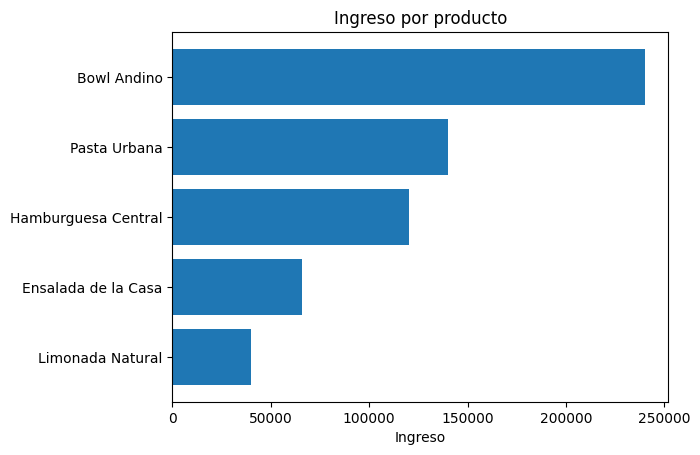

In [ ]:
# TODO E10
fig, ax = plt.subplots()

# Construya aquí la figura
ingreso_producto = kpi_producto.sort_values(by="ingreso")

ax.barh(ingreso_producto.index, ingreso_producto["ingreso"])
ax.set_title("Ingreso por producto")
ax.set_xlabel("Ingreso")

In [ ]:
# Autoevaluación E10
def _comprobar_grafico():
    return (
        isinstance(fig, Figure)
        and ax is not None
        and len(ax.patches) == 5
        and bool(ax.get_title().strip())
        and bool(ax.get_xlabel().strip())
    )

evaluar(
    "E10",
    _comprobar_grafico,
    pistas=[
        "Use kpi_producto['ingreso'].sort_values().plot(kind='barh', ax=ax).",
        "Cree primero fig, ax = plt.subplots(figsize=(8, 4)) y luego agregue título y xlabel.",
    ],
    solucion="""
fig, ax = plt.subplots(figsize=(8, 4))

(
    kpi_producto["ingreso"]
    .sort_values()
    .plot(kind="barh", ax=ax)
)

ax.set_title("Ingresos por producto")
ax.set_xlabel("Ingresos (COP)")
ax.set_ylabel("Producto")
plt.tight_layout()
plt.show()
"""
)

True

# 7. Desafío integrador: resumen ejecutivo automático

Una función analítica debe producir resultados reproducibles a partir de una tabla.

## Ejercicio E11 — Construir un resumen ejecutivo (14 puntos)

Complete `resumen_ejecutivo(df)` para retornar un diccionario con:

- `total_ingresos`;
- `margen_bruto`;
- `porcentaje_margen`;
- `ticket_promedio`;
- `clientes_recurrentes`;
- `tasa_retencion`;
- `producto_lider`;
- `sede_lider`.

### Definiciones

- **Ticket promedio:** ingreso total dividido entre número de transacciones.
- **Clientes recurrentes:** clientes presentes en semana 1 y semana 2.
- **Tasa de retención:** clientes recurrentes / clientes únicos de semana 1 × 100.
- **Porcentaje de margen:** margen bruto / ingreso total × 100.

In [ ]:
# TODO E11
def resumen_ejecutivo(df):
    total_ingresos = df["ingreso"].sum()
    margen_bruto = df["margen_bruto"].sum()
    porcentaje_margen = (margen_bruto / total_ingresos) * 100
    ticket_promedio = total_ingresos / len(df)

    clientes_semana1 = set(df[df["semana"] == 1]["cliente_id"])
    clientes_semana2 = set(df[df["semana"] == 2]["cliente_id"])
    clientes_recurrentes = len(clientes_semana1.intersection(clientes_semana2))
    tasa_retencion = (clientes_recurrentes / len(clientes_semana1)) * 100

    producto_lider = (
        df.groupby("producto")["ingreso"]
        .sum()
        .idxmax()
    )

    sede_lider = (
        df.groupby("sede")["ingreso"]
        .sum()
        .idxmax()
    )

    return {
        "total_ingresos": total_ingresos,
        "margen_bruto": margen_bruto,
        "porcentaje_margen": porcentaje_margen,
        "ticket_promedio": ticket_promedio,
        "clientes_recurrentes": clientes_recurrentes,
        "tasa_retencion": tasa_retencion,
        "producto_lider": producto_lider,
        "sede_lider": sede_lider,
    }

resumen = resumen_ejecutivo(df_ventas)
resumen

{'total_ingresos': np.int64(606000),
 'margen_bruto': np.int64(256500),
 'porcentaje_margen': np.float64(42.32673267326732),
 'ticket_promedio': np.float64(37875.0),
 'clientes_recurrentes': 4,
 'tasa_retencion': 57.14285714285714,
 'producto_lider': 'Bowl Andino',
 'sede_lider': 'Centro'}

In [ ]:
# Autoevaluación E11
def _comprobar_resumen():
    r = resumen_ejecutivo(df_ventas)
    claves = {
        "total_ingresos",
        "margen_bruto",
        "porcentaje_margen",
        "ticket_promedio",
        "clientes_recurrentes",
        "tasa_retencion",
        "producto_lider",
        "sede_lider",
    }

    return (
        isinstance(r, dict)
        and claves.issubset(r.keys())
        and r["total_ingresos"] == 606000
        and r["margen_bruto"] == 256500
        and math.isclose(r["porcentaje_margen"], 42.33, abs_tol=0.01)
        and math.isclose(r["ticket_promedio"], 37875, abs_tol=0.01)
        and r["clientes_recurrentes"] == 4
        and math.isclose(r["tasa_retencion"], 57.14, abs_tol=0.01)
        and r["producto_lider"] == "Bowl Andino"
        and r["sede_lider"] == "Centro"
    )

evaluar(
    "E11",
    _comprobar_resumen,
    pistas=[
        "Separe los clientes de cada semana usando conjuntos set() y calcule su intersección.",
        "Para producto y sede líder, agrupe el ingreso, ordene de mayor a menor y tome el primer índice.",
    ],
    solucion="""
def resumen_ejecutivo(df):
    total_ingresos = df["ingreso"].sum()
    margen_bruto = df["margen_bruto"].sum()
    porcentaje_margen = round(
        margen_bruto / total_ingresos * 100, 2
    )
    ticket_promedio = df["ingreso"].mean()

    clientes_semana_1 = set(
        df.loc[df["semana"] == 1, "cliente_id"]
    )
    clientes_semana_2 = set(
        df.loc[df["semana"] == 2, "cliente_id"]
    )
    recurrentes = clientes_semana_1.intersection(clientes_semana_2)
    tasa_retencion = round(
        len(recurrentes) / len(clientes_semana_1) * 100, 2
    )

    producto_lider = (
        df.groupby("producto")["ingreso"]
        .sum()
        .sort_values(ascending=False)
        .index[0]
    )

    sede_lider = (
        df.groupby("sede")["ingreso"]
        .sum()
        .sort_values(ascending=False)
        .index[0]
    )

    return {
        "total_ingresos": total_ingresos,
        "margen_bruto": margen_bruto,
        "porcentaje_margen": porcentaje_margen,
        "ticket_promedio": ticket_promedio,
        "clientes_recurrentes": len(recurrentes),
        "tasa_retencion": tasa_retencion,
        "producto_lider": producto_lider,
        "sede_lider": sede_lider,
    }

resumen = resumen_ejecutivo(df_ventas)
resumen
"""
)

True

### 1. ¿Qué significa para la gerencia un margen bruto cercano al 42 %?

Para la gerencia, un margen bruto cercano al 42 % significa que, después de cubrir los costos de los productos, todavía queda un 42 % de los ingresos como ganancia bruta. Esto indica que el negocio está siendo rentable, aunque siempre es importante seguir buscando formas de reducir costos o aumentar las ventas para mejorar ese resultado.

### 2. ¿Por qué no basta con conocer el producto con mayores ingresos?

Porque un producto puede ser el que más vende, pero eso no quiere decir que sea el que más ganancias deje. También hay que mirar cuánto cuesta producirlo o venderlo, ya que un producto con menores ingresos puede generar un mejor margen de ganancia.

### 3. ¿Qué acción recomendaría para mejorar la retención?

Una buena opción sería crear promociones o beneficios para los clientes que compran con frecuencia. También se podrían ofrecer descuentos en compras futuras o implementar un programa de fidelización para motivarlos a regresar.

### 4. ¿Qué limitación tiene este análisis al utilizar solamente dos semanas?

La principal limitación es que dos semanas son muy poco tiempo para sacar conclusiones definitivas. En ese período pueden ocurrir situaciones que no representan el comportamiento normal del negocio, por lo que sería mejor analizar información de varios meses para tomar decisiones con mayor confianza.



# 9. Resultado final y exportación

Ejecute las dos celdas siguientes.

- Un resultado de **80 puntos o más** indica dominio suficiente para avanzar.
- Entre **60 y 79 puntos**, revise los ejercicios pendientes.
- Menos de **60 puntos**, repita la sección de fundamentos antes de continuar.

In [ ]:
mostrar_progreso()

In [ ]:
nombre_estudiante = "samuel pardo"

exportar_autoevaluacion(
    nombre_estudiante if nombre_estudiante else "estudiante"
)

print(nombre_estudiante)

Archivo creado: autoevaluacion_python_samuel_pardo.csv


,estudiante,ejercicio,puntaje_obtenido,puntaje_maximo,intentos
0,samuel pardo,E1,8,8,0
1,samuel pardo,E2,5,5,0
2,samuel pardo,E3,8,8,0
3,samuel pardo,E4,8,8,0
4,samuel pardo,E5,8,8,0
5,samuel pardo,E6,10,10,0
6,samuel pardo,E7,10,10,0
7,samuel pardo,E8,10,10,0
8,samuel pardo,E9,12,12,0
9,samuel pardo,E10,7,7,0


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

samuel pardo


# 10. Lista de comprobación

Antes de entregar:

- [ ] guardé una copia del cuaderno en Drive;
- [ ] ejecuté todas las celdas en orden;
- [ ] obtuve al menos 80/100;
- [ ] respondí la interpretación profesional;
- [ ] compartí el enlace al cuaderno según las instrucciones del profesor.

---

# Recursos oficiales de consulta

- [Preguntas frecuentes de Google Colab](https://research.google.com/colaboratory/intl/es/faq.html)
- [Tutorial oficial de Python](https://docs.python.org/es/3/tutorial/index.html)
- [Introducción oficial a pandas](https://pandas.pydata.org/docs/getting_started/)
- [Guía de inicio de Matplotlib](https://matplotlib.org/stable/users/getting_started/)

## Mensaje de cierre

> Programar para analítica no consiste en memorizar instrucciones.  
> Consiste en traducir una pregunta de negocio a pasos verificables, reproducibles e interpretables.